# ระบบทำนายเมนูกาแฟที่ลูกค้ามีแนวโน้มจะสั่งซื้อ ด้วย Machine Learning

โน้ตบุ๊กนี้รวมขั้นตอนทั้งหมดของโครงงาน: สำรวจข้อมูล (EDA) → คัดเลือกฟีเจอร์ → เปรียบเทียบโมเดล →
เทรนโมเดลสุดท้าย (Gradient Boosting Classifier) → ประเมินผล → ปรับ Hyperparameter → วัดผลแบบ
Top-k Accuracy → บันทึกโมเดล

**วิธีใช้ใน Google Colab:**
1. รันเซลล์ด้านล่างเพื่ออัปโหลดไฟล์ `Coffe_sales.csv` (จะมีปุ่มให้เลือกไฟล์จากเครื่อง)
2. รันเซลล์ที่เหลือตามลำดับตั้งแต่บนลงล่าง (Runtime → Run all ก็ได้)


## 0. ติดตั้ง/นำเข้าไลบรารี และโหลดข้อมูล

In [1]:
import sys
IN_COLAB = "google.colab" in sys.modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [2]:
# ถ้ารันบน Google Colab ให้อัปโหลดไฟล์ Coffe_sales.csv จากเครื่องของคุณ
# ถ้ารันบนเครื่องตัวเอง (Jupyter local) ให้วางไฟล์ Coffe_sales.csv ไว้โฟลเดอร์เดียวกับโน้ตบุ๊กนี้แทน

if IN_COLAB:
    from google.colab import files
    uploaded = files.upload()  # เลือกไฟล์ Coffe_sales.csv
    csv_path = list(uploaded.keys())[0]
else:
    csv_path = "Coffe_sales.csv"

df = pd.read_csv(csv_path)
print(df.shape)
df.head()


(3547, 11)


,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


## 1. Exploratory Data Analysis (EDA)

สำรวจข้อมูลก่อนตัดสินใจเลือกฟีเจอร์ เพื่อตรวจสอบ missing values, การกระจายของ Target,
และความเสี่ยงเรื่อง Data Leakage

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   str    
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   str    
 4   Time_of_Day  3547 non-null   str    
 5   Weekday      3547 non-null   str    
 6   Month_name   3547 non-null   str    
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   str    
 10  Time         3547 non-null   str    
dtypes: float64(1), int64(3), str(7)
memory usage: 304.9 KB


In [4]:
print("จำนวนค่าขาดหาย (missing values) ต่อคอลัมน์:")
print(df.isnull().sum())


จำนวนค่าขาดหาย (missing values) ต่อคอลัมน์:
hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64


In [5]:
print("ค่าที่พบในคอลัมน์ cash_type:", df["cash_type"].unique())


ค่าที่พบในคอลัมน์ cash_type: <StringArray>
['card']
Length: 1, dtype: str


coffee_name
Americano with Milk    809
Latte                  757
Americano              564
Cappuccino             486
Cortado                287
Hot Chocolate          276
Cocoa                  239
Espresso               129
Name: count, dtype: int64

สัดส่วน (%):
coffee_name
Americano with Milk    22.8
Latte                  21.3
Americano              15.9
Cappuccino             13.7
Cortado                 8.1
Hot Chocolate           7.8
Cocoa                   6.7
Espresso                3.6
Name: count, dtype: float64


C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\89126287.py:11: UserWarning: Glyph 3592 (\N{THAI CHARACTER CHO CHAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\89126287.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\89126287.py:11: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\89126287.py:11: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\89126287.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\89126287.py:11: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YA

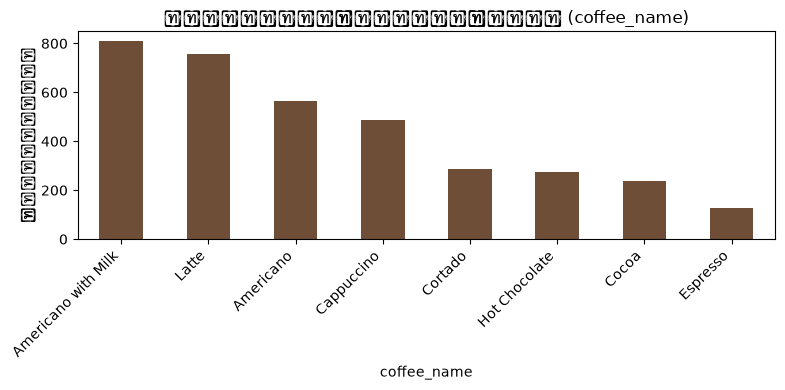

In [6]:
coffee_counts = df["coffee_name"].value_counts()
print(coffee_counts)
print()
print("สัดส่วน (%):")
print((coffee_counts / len(df) * 100).round(1))

coffee_counts.plot(kind="bar", figsize=(8, 4), color="#6f4e37")
plt.title("การกระจายตัวของเมนูกาแฟ (coffee_name)")
plt.ylabel("จำนวนรายการ")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [7]:
# ตรวจสอบว่า money ผูกกับ coffee_name เกือบสมบูรณ์หรือไม่ (สัญญาณ Data Leakage)
df.groupby("coffee_name")["money"].unique()


coffee_name
Americano              [28.9, 27.92, 23.02, 25.96]
Americano with Milk    [33.8, 32.82, 27.92, 30.86]
Cappuccino             [38.7, 37.72, 32.82, 35.76]
Cocoa                  [38.7, 37.72, 32.82, 35.76]
Cortado                [28.9, 27.92, 23.02, 25.96]
Espresso               [24.0, 23.02, 18.12, 21.06]
Hot Chocolate          [38.7, 37.72, 32.82, 35.76]
Latte                  [38.7, 37.72, 32.82, 35.76]
Name: money, dtype: object

**ข้อสังเกตจาก EDA:**
- ไม่มี missing values เลยในทุกคอลัมน์
- `cash_type` มีค่าเดียวคือ `"card"` ตลอดทั้งชุดข้อมูล → ไม่มีประโยชน์ต่อการทำนาย ตัดทิ้ง
- `coffee_name` มีลักษณะ Class Imbalance ชัดเจน (Americano with Milk 22.8% vs Espresso 3.6%)
- `money` ผูกกับ `coffee_name` เกือบสมบูรณ์ (แต่ละเมนูมีช่วงราคาเฉพาะของตัวเอง) → ถ้าใช้เป็น
  Feature จะเกิด **Data Leakage** เพราะในความเป็นจริง ราคาจะรู้ได้ก็ต่อเมื่อรู้เมนูที่ลูกค้าเลือกแล้ว

## 2. Feature Selection & Preprocessing

เลือกใช้เฉพาะฟีเจอร์ที่ **รู้ล่วงหน้าได้จริง** ก่อนลูกค้าจะสั่งเมนู: `Weekday`, `Month_name`,
`Time_of_Day` — ตัด `money` (data leakage), `cash_type` (ไม่มีความแปรปรวน), `hour_of_day`
(ซ้ำซ้อนกับ Time_of_Day และละเอียดเกินไปจนเกิด overfitting), `Date`/`Time`/`Weekdaysort`/
`Monthsort` (ซ้ำซ้อนกับตัวแปรอื่นที่เลือกใช้แล้ว)

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

FEATURES = ["Weekday", "Month_name", "Time_of_Day"]
TARGET = "coffee_name"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)

preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES)]
)


Train: (2837, 3)  Test: (710, 3)


## 3. เปรียบเทียบโมเดล (Model Comparison)

ทดลอง 3 โมเดลบนฟีเจอร์ชุดเดียวกัน เพื่อเลือกโมเดลที่เหมาะสมที่สุด

Baseline accuracy (เดา 'Americano with Milk' ทุกครั้ง): 0.228

Logistic Regression            accuracy = 0.194
Random Forest (max_depth=6)    accuracy = 0.200
Gradient Boosting              accuracy = 0.286


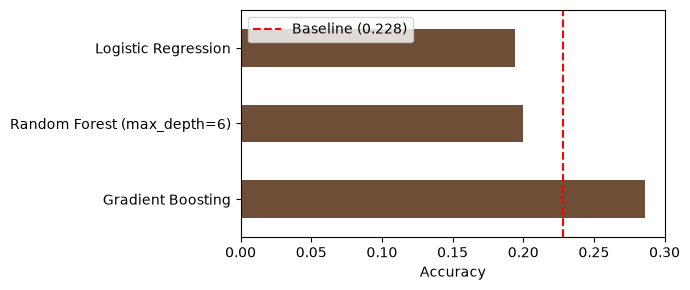

In [9]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

baseline_acc = y.value_counts(normalize=True).max()
print(f"Baseline accuracy (เดา '{y.value_counts().idxmax()}' ทุกครั้ง): {baseline_acc:.3f}\n")

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest (max_depth=6)": RandomForestClassifier(
        n_estimators=300, max_depth=6, class_weight="balanced", random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

results = {}
for name, clf in candidates.items():
    pipe = Pipeline([("pre", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_test))
    results[name] = acc
    print(f"{name:30s} accuracy = {acc:.3f}")

pd.Series(results).sort_values(ascending=False).plot(
    kind="barh", figsize=(7, 3), color="#6f4e37"
)
plt.axvline(baseline_acc, color="red", linestyle="--", label=f"Baseline ({baseline_acc:.3f})")
plt.xlabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


**สรุป:** Gradient Boosting Classifier ให้ accuracy สูงสุด จึงเลือกเป็นโมเดลหลักของโครงงาน
(ดูเหตุผลเชิงทฤษฎีเพิ่มเติมได้ในเอกสาร `ความรู้ประกอบโครงงาน_ML.md`)

## 4. เทรนโมเดลสุดท้าย: Gradient Boosting Classifier

In [10]:
from sklearn.metrics import classification_report, confusion_matrix

final_pipeline = Pipeline([("pre", preprocessor), ("clf", GradientBoostingClassifier(random_state=42))])
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Baseline accuracy:      {baseline_acc:.3f}")
print(f"Model accuracy (Top-1): {acc:.3f}\n")
print(classification_report(y_test, y_pred))


Baseline accuracy:      0.228
Model accuracy (Top-1): 0.286

                     precision    recall  f1-score   support

          Americano       0.34      0.42      0.38       113
Americano with Milk       0.29      0.35      0.31       162
         Cappuccino       0.24      0.16      0.20        97
              Cocoa       0.29      0.21      0.24        48
            Cortado       0.18      0.11      0.13        57
           Espresso       0.00      0.00      0.00        26
      Hot Chocolate       0.30      0.27      0.29        55
              Latte       0.29      0.34      0.31       152

           accuracy                           0.29       710
          macro avg       0.24      0.23      0.23       710
       weighted avg       0.27      0.29      0.27       710



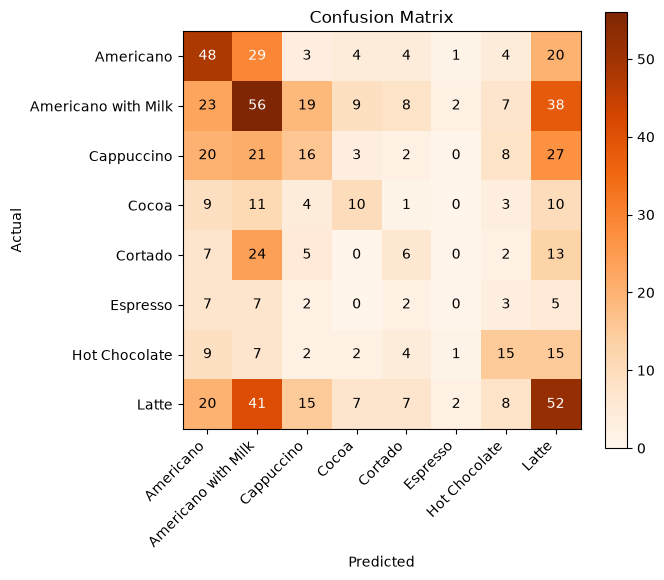

In [11]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Oranges")
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.show()


Month_name     0.423352
Time_of_Day    0.288997
Weekday        0.287651
dtype: float64


C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\2901027081.py:19: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\2901027081.py:19: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\2901027081.py:19: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\2901027081.py:19: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\2901027081.py:19: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\naza1144\AppData\Local\Temp\ipykernel_31800\2901027081.py:19: UserWarning: Glyph 3597 (\N{THAI CH

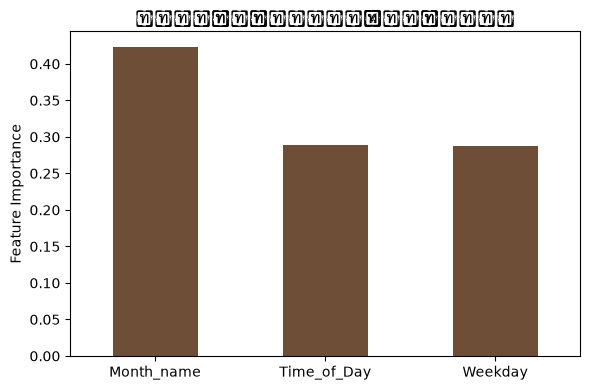

In [12]:
# Feature Importance รวมกลับเป็นตัวแปรต้นฉบับ
feature_names = final_pipeline.named_steps["pre"].get_feature_names_out()
importances = final_pipeline.named_steps["clf"].feature_importances_

import re
agg = {}
for name, imp in zip(feature_names, importances):
    m = re.match(r"cat__(Weekday|Month_name|Time_of_Day)_", name)
    key = m.group(1) if m else name
    agg[key] = agg.get(key, 0) + imp

importance_series = pd.Series(agg).sort_values(ascending=False)
print(importance_series)

importance_series.plot(kind="bar", figsize=(6, 4), color="#6f4e37")
plt.ylabel("Feature Importance")
plt.title("ความสำคัญของแต่ละตัวแปร")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Hyperparameter Tuning (GridSearchCV)

ทดลองค้นหาค่าพารามิเตอร์ที่ดีที่สุดด้วย 5-fold Cross Validation แล้วเทียบกับค่า default

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [2, 3, 4],
}

grid_pipeline = Pipeline([("pre", preprocessor), ("clf", GradientBoostingClassifier(random_state=42))])
grid = GridSearchCV(grid_pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params from GridSearchCV:", grid.best_params_)
print(f"Best CV accuracy: {grid.best_score_:.3f}\n")

tuned_pred = grid.best_estimator_.predict(X_test)
tuned_acc = accuracy_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred, average="macro")
default_f1 = f1_score(y_test, y_pred, average="macro")

comparison = pd.DataFrame({
    "Before tuning (default)": [acc, default_f1],
    "After tuning (GridSearchCV)": [tuned_acc, tuned_f1],
}, index=["Accuracy", "Macro F1-score"])
comparison


Best params from GridSearchCV: {'clf__learning_rate': 0.01, 'clf__max_depth': 2, 'clf__n_estimators': 300}
Best CV accuracy: 0.265



,Before tuning (default),After tuning (GridSearchCV)
Accuracy,0.285915,0.271831
Macro F1-score,0.231996,0.176169


**ข้อค้นพบ:** ค่าพารามิเตอร์ที่ได้จาก GridSearchCV ให้ผลบนชุด Test **แย่กว่า** ค่า default
ทั้ง Accuracy และ Macro F1-score เพราะ Cross-validation Accuracy ที่ใช้เลือกพารามิเตอร์ต่ำกว่า
Test Accuracy ของค่า default อยู่แล้ว แสดงว่าคอขวดที่แท้จริงคือคุณภาพของสัญญาณในฟีเจอร์
ไม่ใช่การตั้งค่าโมเดล จึงตัดสินใจ**ใช้ค่า default ต่อไปในระบบจริง**

## 6. Top-k Accuracy: มุมมองแบบ "เมนูแนะนำ"

แทนที่จะฟันธงเมนูเดียว (Top-1) ลองดูว่าคำตอบจริงอยู่ใน k อันดับแรกที่โมเดลให้ความน่าจะเป็นสูงสุด
หรือไม่ — เหมาะกับระบบที่แสดงผลเป็นรายการเมนูแนะนำ (เหมือนหน้าเว็บของโครงงานนี้)

Top-1    0.285915
Top-2    0.511268
Top-3    0.663380
Top-4    0.776056
dtype: float64


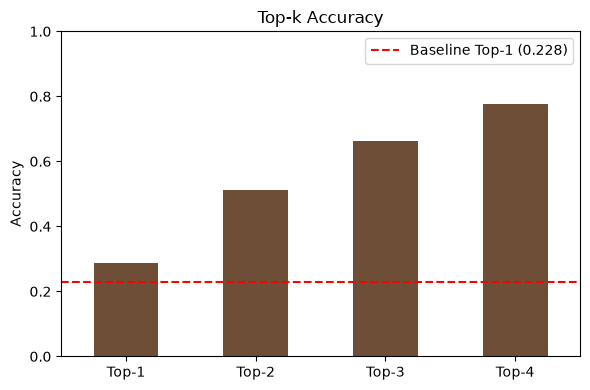

In [14]:
from sklearn.metrics import top_k_accuracy_score

proba = final_pipeline.predict_proba(X_test)
model_classes = final_pipeline.named_steps["clf"].classes_

topk_results = {}
for k in [1, 2, 3, 4]:
    topk_results[f"Top-{k}"] = top_k_accuracy_score(y_test, proba, k=k, labels=model_classes)

topk_series = pd.Series(topk_results)
print(topk_series)

topk_series.plot(kind="bar", figsize=(6, 4), color="#6f4e37")
plt.ylabel("Accuracy")
plt.title("Top-k Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.axhline(baseline_acc, color="red", linestyle="--", label=f"Baseline Top-1 ({baseline_acc:.3f})")
plt.legend()
plt.tight_layout()
plt.show()


## 7. บันทึกโมเดล

บันทึกโมเดลที่เทรนเสร็จแล้ว (พร้อมข้อมูลประกอบ) เป็นไฟล์ `.joblib` สำหรับนำไปใช้ในเว็บแอปพลิเคชัน
(Flask) ต่อไป ถ้ารันบน Colab ไฟล์จะถูกดาวน์โหลดกลับมาที่เครื่องของคุณอัตโนมัติ

In [15]:
import joblib

WEEKDAY_ORDER = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
MONTH_ORDER = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
TIME_OF_DAY_ORDER = ["Morning", "Afternoon", "Night"]

model_path = "coffee_model.joblib"
joblib.dump(
    {
        "pipeline": final_pipeline,
        "classes": sorted(y.unique()),
        "weekday_order": WEEKDAY_ORDER,
        "month_order": MONTH_ORDER,
        "time_of_day_order": TIME_OF_DAY_ORDER,
        "test_accuracy": acc,
        "baseline_accuracy": baseline_acc,
        "top_k": 4,
        "top_k_accuracy": topk_results["Top-4"],
    },
    model_path,
)
print(f"Saved model to {model_path}")

if IN_COLAB:
    from google.colab import files
    files.download(model_path)


Saved model to coffee_model.joblib


## สรุป

- **Top-1 Accuracy:** ~28.6% (เทียบกับ Baseline ~22.8%)
- **Top-4 Accuracy:** ~77.6%
- โมเดลที่เลือกใช้: **Gradient Boosting Classifier** (ดีที่สุดในบรรดา Logistic Regression / Random Forest / Gradient Boosting ที่ทดลอง)
- การปรับ Hyperparameter ด้วย GridSearchCV ไม่ได้ช่วยให้ผลลัพธ์ดีขึ้น เพราะคอขวดอยู่ที่สัญญาณจากฟีเจอร์ ไม่ใช่การตั้งค่าโมเดล
- รายละเอียดเพิ่มเติม (เหตุผลเชิงลึก, คำศัพท์, การนำไปใช้งานจริง) อยู่ในเอกสาร `รายงานโครงงาน_ML.docx/.md` และ `ความรู้ประกอบโครงงาน_ML.md`